In [24]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name.lower() == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR

DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
GEO_DIR = PROJECT_DIR / "data" / "raw" / "geography"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "maps" / "k7_preston"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ASSIGNMENTS_PATH = (
    DATA_PROCESSED_DIR
    / "k_comparison_outputs_v1"
    / "oa_assignments"
    / "k7_oa_cluster_assignments_v1.csv"
)

# Change this filename to match your actual OA boundary GeoPackage
OA_BOUNDARIES_PATH = "C:\\Users\\keena\\Documents\\Electoral_Tribes\\data\\geography\\OA_2021_boundaries.gpkg"
WARD_BOUNDARIES_PATH = "C:\\Users\\keena\\Documents\\Electoral_Tribes\\data\\geography\\Wards_May_2025_Boundaries_UK_BGC.gpkg"

print("Project:", PROJECT_DIR)
print("Assignments:", ASSIGNMENTS_PATH)
print("Boundaries:", OA_BOUNDARIES_PATH)

Project: c:\Users\keena\Documents\Electoral_Tribes
Assignments: c:\Users\keena\Documents\Electoral_Tribes\data\processed\k_comparison_outputs_v1\oa_assignments\k7_oa_cluster_assignments_v1.csv
Boundaries: C:\Users\keena\Documents\Electoral_Tribes\data\geography\OA_2021_boundaries.gpkg


In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.colors import ListedColormap

In [4]:
assignments = pd.read_csv(ASSIGNMENTS_PATH)

print(assignments.shape)
print(assignments.columns.tolist())
display(assignments.head())

(188880, 3)
['oa_code', 'cluster_id', 'population']


,oa_code,cluster_id,population
0,E00000001,3,176
1,E00000003,3,256
2,E00000005,3,112
3,E00000007,3,144
4,E00000010,3,178


In [5]:
assignments = assignments.rename(columns={
    "oa_code": "OA21CD",
    "cluster_id": "cluster_id",
    "population": "population"
})

assignments["OA21CD"] = assignments["OA21CD"].astype(str).str.strip()
assignments["cluster_id"] = assignments["cluster_id"].astype(int)

assignments.head()

,OA21CD,cluster_id,population
0,E00000001,3,176
1,E00000003,3,256
2,E00000005,3,112
3,E00000007,3,144
4,E00000010,3,178


In [9]:
import pyogrio

layers = pyogrio.list_layers(OA_BOUNDARIES_PATH)
layers

array([['OA_2021_EW_BFE_V9', 'MultiPolygon']], dtype=object)

In [10]:
oa_boundaries = gpd.read_file(OA_BOUNDARIES_PATH)

print(oa_boundaries.shape)
print(oa_boundaries.columns.tolist())
print(oa_boundaries.crs)
display(oa_boundaries.head())

(188880, 10)
['OA21CD', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'GlobalID', 'geometry']
EPSG:27700


,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E00000001,E01000001,City of London 001A,,532250,181864,51.520222,-0.09523,{C981DC33-FE6F-4D55-A084-D12E5D0221E2},"MULTIPOLYGON (((532303.125 181877.594, 532305...."
1,E00000003,E01000001,City of London 001A,,532171,181819,51.519829,-0.09638,{D13E6E18-BD34-4B31-8807-DA0EAB800E0F},"MULTIPOLYGON (((532198.818 181863.087, 532197...."
2,E00000005,E01000001,City of London 001A,,532166,181722,51.518959,-0.09649,{1695F2EB-EC12-484D-BFB1-89308BD386BE},"MULTIPOLYGON (((532178.979 181764.041, 532163...."
3,E00000007,E01000001,City of London 001A,,532088,181473,51.516739,-0.09771,{98128F38-F049-4A66-A3A9-B10189281AA9},"MULTIPOLYGON (((532160 181671, 532156.225 1816..."
4,E00000010,E01000003,City of London 001C,,532092,182114,51.522499,-0.09741,{C84FF0E9-3132-424C-8E27-CB038F7EEE59},"MULTIPOLYGON (((532127.958 182133.192, 532074...."


In [11]:
possible_oa_cols = ["OA21CD", "oa21cd", "OA_CODE", "oa_code", "geography code"]

oa_code_col = None

for col in possible_oa_cols:
    if col in oa_boundaries.columns:
        oa_code_col = col
        break

if oa_code_col is None:
    raise KeyError("Could not find an OA code column in the boundary file.")

oa_boundaries = oa_boundaries.rename(columns={oa_code_col: "OA21CD"})
oa_boundaries["OA21CD"] = oa_boundaries["OA21CD"].astype(str).str.strip()

oa_boundaries = oa_boundaries[["OA21CD", "geometry"]].copy()
oa_boundaries.head()

,OA21CD,geometry
0,E00000001,"MULTIPOLYGON (((532303.125 181877.594, 532305...."
1,E00000003,"MULTIPOLYGON (((532198.818 181863.087, 532197...."
2,E00000005,"MULTIPOLYGON (((532178.979 181764.041, 532163...."
3,E00000007,"MULTIPOLYGON (((532160 181671, 532156.225 1816..."
4,E00000010,"MULTIPOLYGON (((532127.958 182133.192, 532074...."


In [12]:
if oa_boundaries.crs is None:
    oa_boundaries = oa_boundaries.set_crs(27700)

if oa_boundaries.crs.to_epsg() != 27700:
    oa_boundaries = oa_boundaries.to_crs(27700)

print(oa_boundaries.crs)

EPSG:27700


In [13]:
oa_map = oa_boundaries.merge(
    assignments,
    on="OA21CD",
    how="inner",
    validate="one_to_one"
)

print("Boundary rows:", len(oa_boundaries))
print("Assignment rows:", len(assignments))
print("Mapped rows:", len(oa_map))

display(oa_map.head())

Boundary rows: 188880
Assignment rows: 188880
Mapped rows: 188880


,OA21CD,geometry,cluster_id,population
0,E00000001,"MULTIPOLYGON (((532303.125 181877.594, 532305....",3,176
1,E00000003,"MULTIPOLYGON (((532198.818 181863.087, 532197....",3,256
2,E00000005,"MULTIPOLYGON (((532178.979 181764.041, 532163....",3,112
3,E00000007,"MULTIPOLYGON (((532160 181671, 532156.225 1816...",3,144
4,E00000010,"MULTIPOLYGON (((532127.958 182133.192, 532074....",3,178


In [14]:
oa_map = oa_boundaries.merge(
    assignments,
    on="OA21CD",
    how="inner",
    validate="one_to_one"
)

print("Boundary rows:", len(oa_boundaries))
print("Assignment rows:", len(assignments))
print("Mapped rows:", len(oa_map))

display(oa_map.head())

Boundary rows: 188880
Assignment rows: 188880
Mapped rows: 188880


,OA21CD,geometry,cluster_id,population
0,E00000001,"MULTIPOLYGON (((532303.125 181877.594, 532305....",3,176
1,E00000003,"MULTIPOLYGON (((532198.818 181863.087, 532197....",3,256
2,E00000005,"MULTIPOLYGON (((532178.979 181764.041, 532163....",3,112
3,E00000007,"MULTIPOLYGON (((532160 181671, 532156.225 1816...",3,144
4,E00000010,"MULTIPOLYGON (((532127.958 182133.192, 532074....",3,178


In [15]:
# Preston city centre approximate longitude/latitude
preston_lon = -2.6993
preston_lat = 53.7632

preston_point = gpd.GeoDataFrame(
    {"name": ["Preston"]},
    geometry=[Point(preston_lon, preston_lat)],
    crs="EPSG:4326"
).to_crs(27700)

# Radius in metres
radius_m = 12_000

preston_buffer = preston_point.buffer(radius_m).iloc[0]

preston_oa = oa_map[oa_map.intersects(preston_buffer)].copy()

print(preston_oa.shape)
print(preston_oa["cluster_id"].value_counts().sort_index())

(1173, 4)
cluster_id
0     30
1    364
2    274
3     13
4    248
5     74
6    170
Name: count, dtype: int64


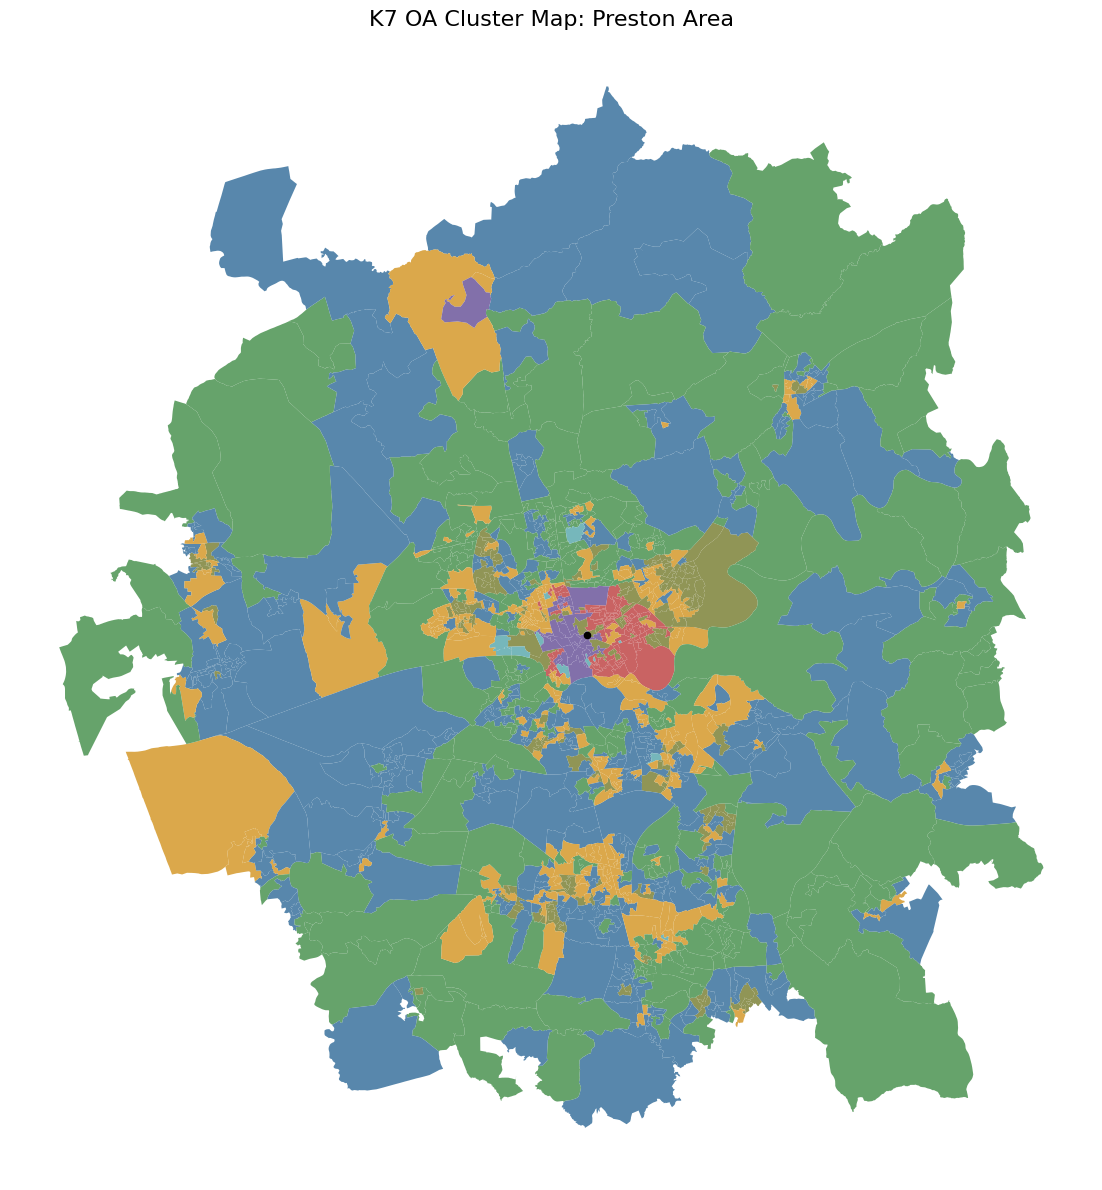

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_oa_clusters.png


In [16]:
cluster_palette = {
    0: "#7B68A6",
    1: "#4F81A8",
    2: "#5E9E63",
    3: "#6FB3B8",
    4: "#D9A441",
    5: "#C65B5B",
    6: "#8A8F4D",
}

preston_oa["cluster_colour"] = preston_oa["cluster_id"].map(cluster_palette)

fig, ax = plt.subplots(figsize=(12, 12))

preston_oa.plot(
    ax=ax,
    color=preston_oa["cluster_colour"],
    linewidth=0,
    alpha=0.95
)

preston_point.plot(
    ax=ax,
    color="black",
    markersize=20
)

ax.set_title("K7 OA Cluster Map: Preston Area", fontsize=16)
ax.set_axis_off()

plt.tight_layout()

out_path = OUTPUT_DIR / "k7_preston_oa_clusters.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

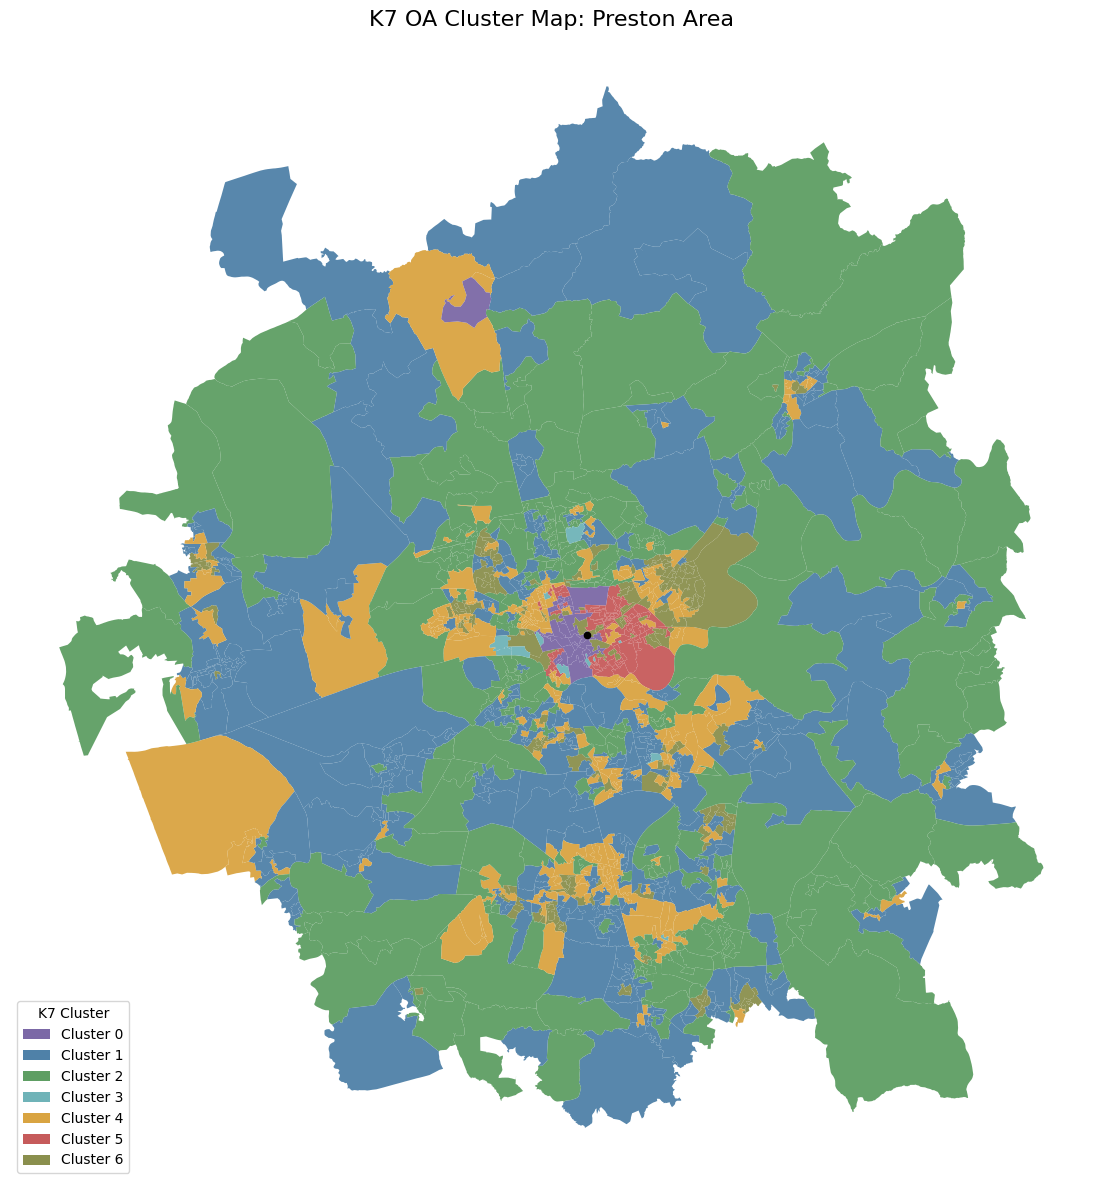

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_oa_clusters_legend.png


In [17]:
from matplotlib.patches import Patch

legend_items = [
    Patch(facecolor=cluster_palette[i], label=f"Cluster {i}")
    for i in sorted(preston_oa["cluster_id"].unique())
]

fig, ax = plt.subplots(figsize=(12, 12))

preston_oa.plot(
    ax=ax,
    color=preston_oa["cluster_colour"],
    linewidth=0,
    alpha=0.95
)

preston_point.plot(
    ax=ax,
    color="black",
    markersize=20
)

ax.legend(
    handles=legend_items,
    title="K7 Cluster",
    loc="lower left",
    frameon=True
)

ax.set_title("K7 OA Cluster Map: Preston Area", fontsize=16)
ax.set_axis_off()

plt.tight_layout()

out_path = OUTPUT_DIR / "k7_preston_oa_clusters_legend.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [18]:
preston_cluster_summary = (
    preston_oa
    .groupby("cluster_id", as_index=False)
    .agg(
        oa_count=("OA21CD", "count"),
        population=("population", "sum")
    )
)

preston_cluster_summary["oa_share"] = (
    preston_cluster_summary["oa_count"]
    / preston_cluster_summary["oa_count"].sum()
)

preston_cluster_summary["population_share"] = (
    preston_cluster_summary["population"]
    / preston_cluster_summary["population"].sum()
)

preston_cluster_summary = preston_cluster_summary.sort_values(
    "population_share",
    ascending=False
)

display(preston_cluster_summary)

preston_cluster_summary.to_csv(
    OUTPUT_DIR / "k7_preston_cluster_summary.csv",
    index=False
)

,cluster_id,oa_count,population,oa_share,population_share
1,1,364,103771,0.310315,0.285675
2,2,274,92086,0.233589,0.253507
4,4,248,77431,0.211424,0.213162
6,6,170,47483,0.144928,0.130717
5,5,74,26849,0.063086,0.073913
0,0,30,12408,0.025575,0.034158
3,3,13,3221,0.011083,0.008867


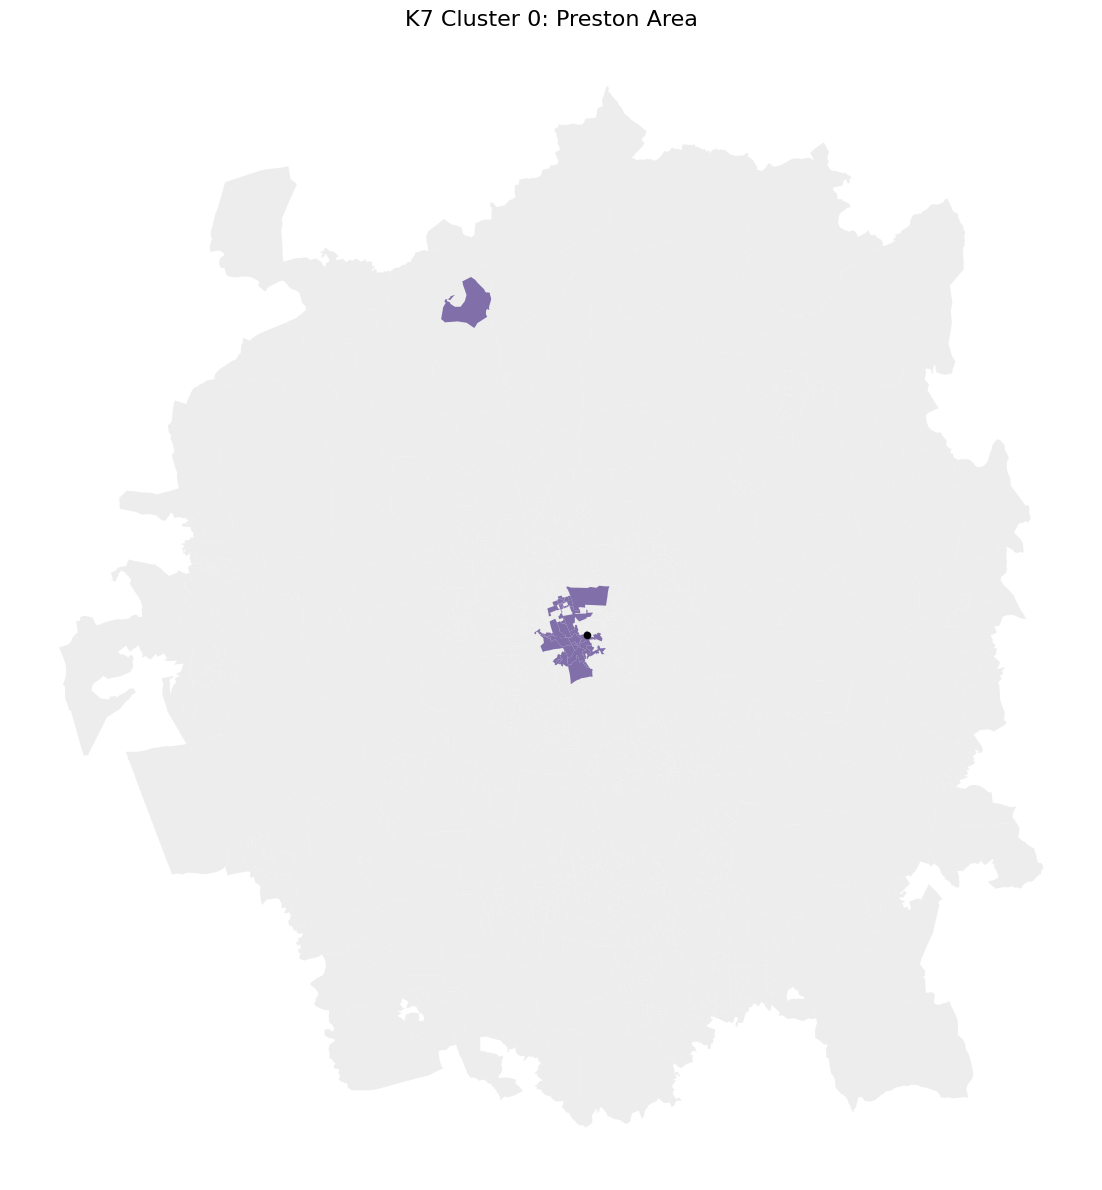

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_0_highlight.png


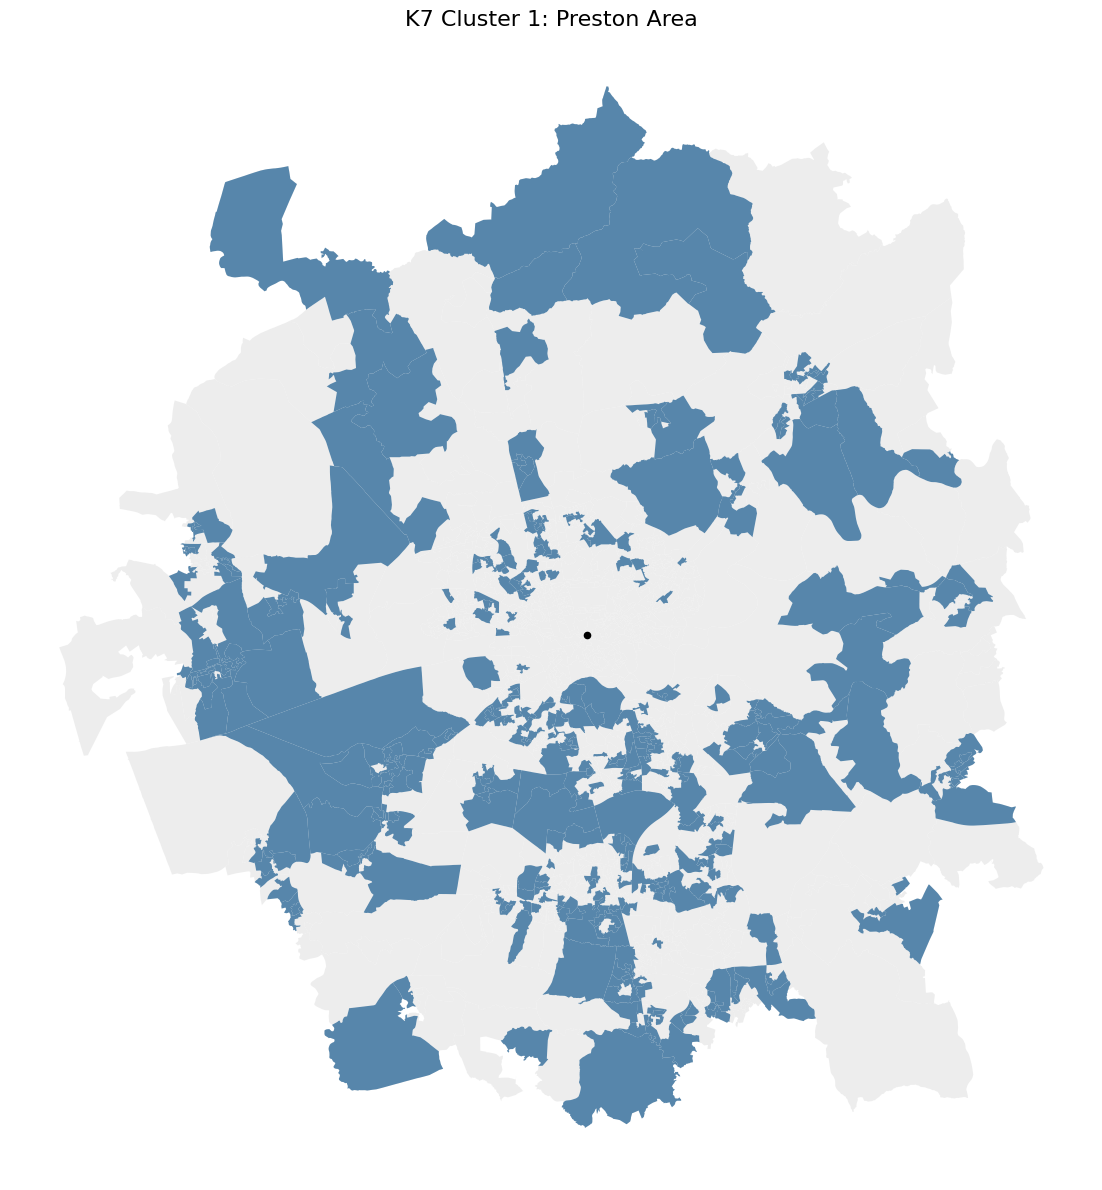

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_1_highlight.png


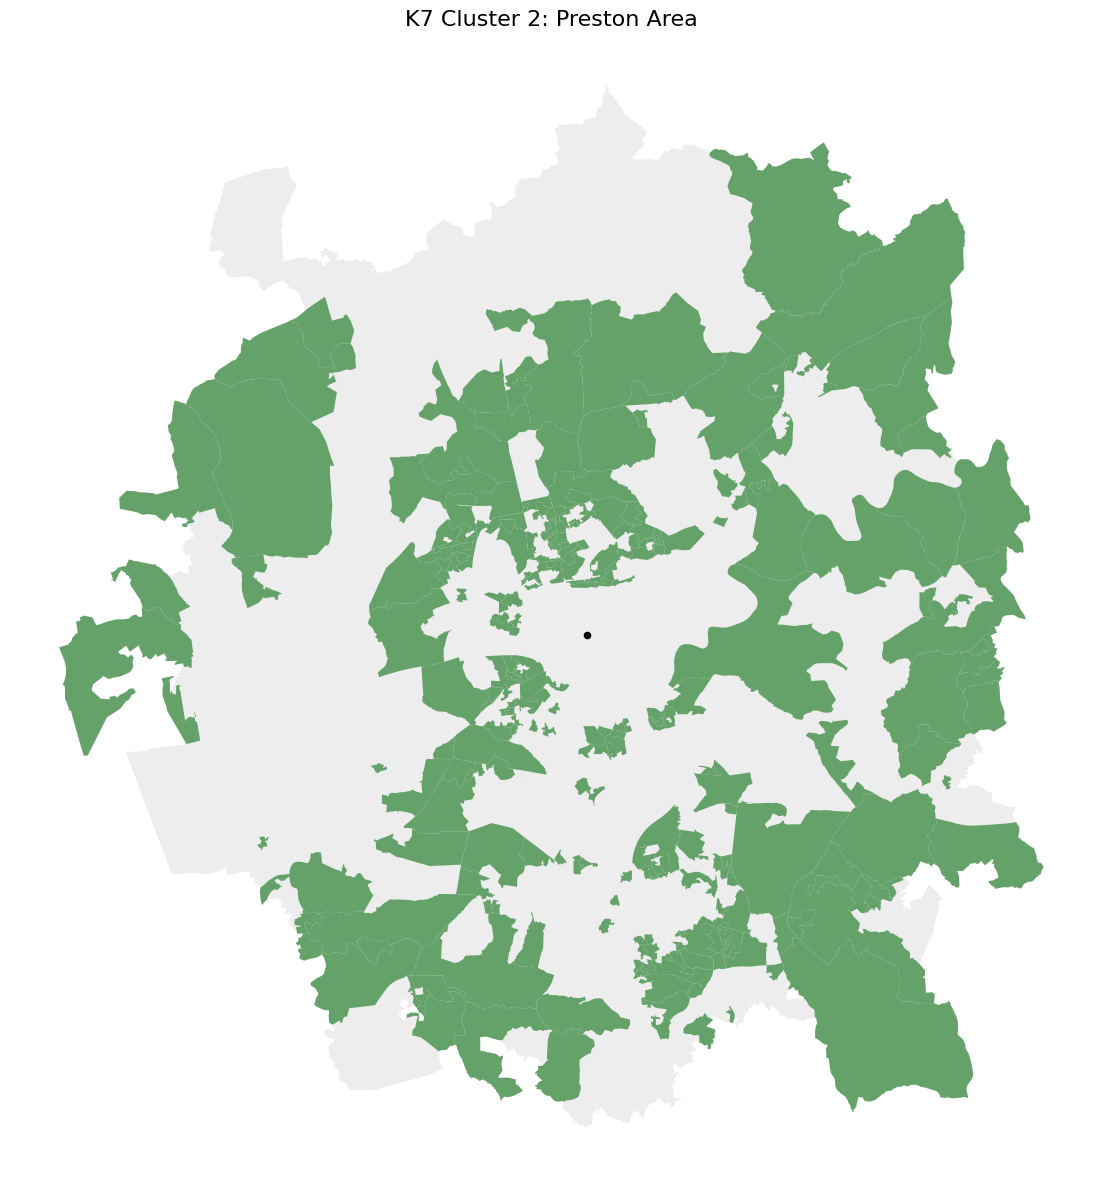

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_2_highlight.png


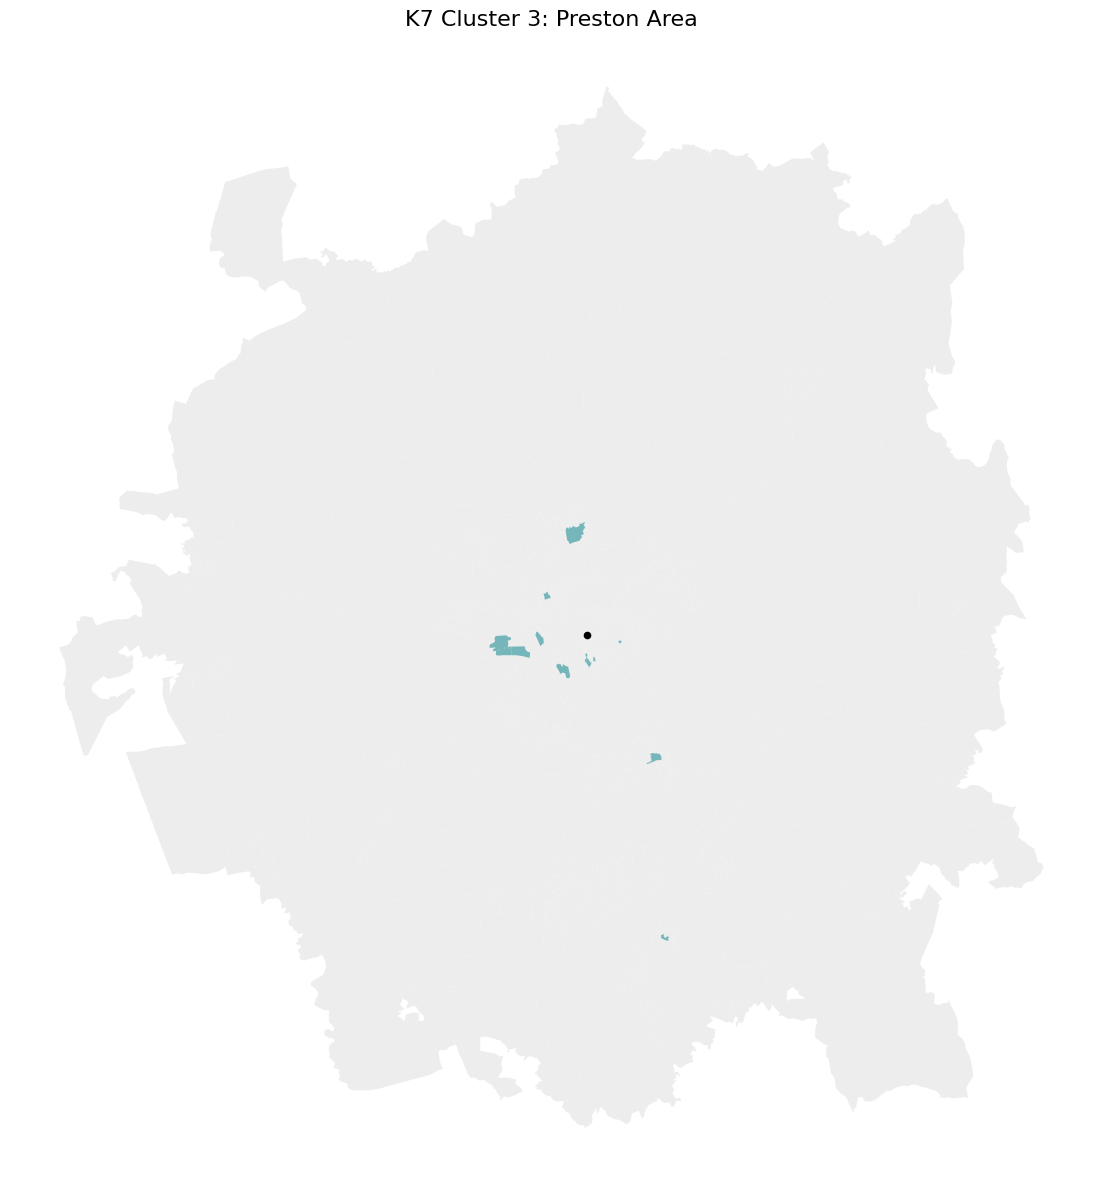

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_3_highlight.png


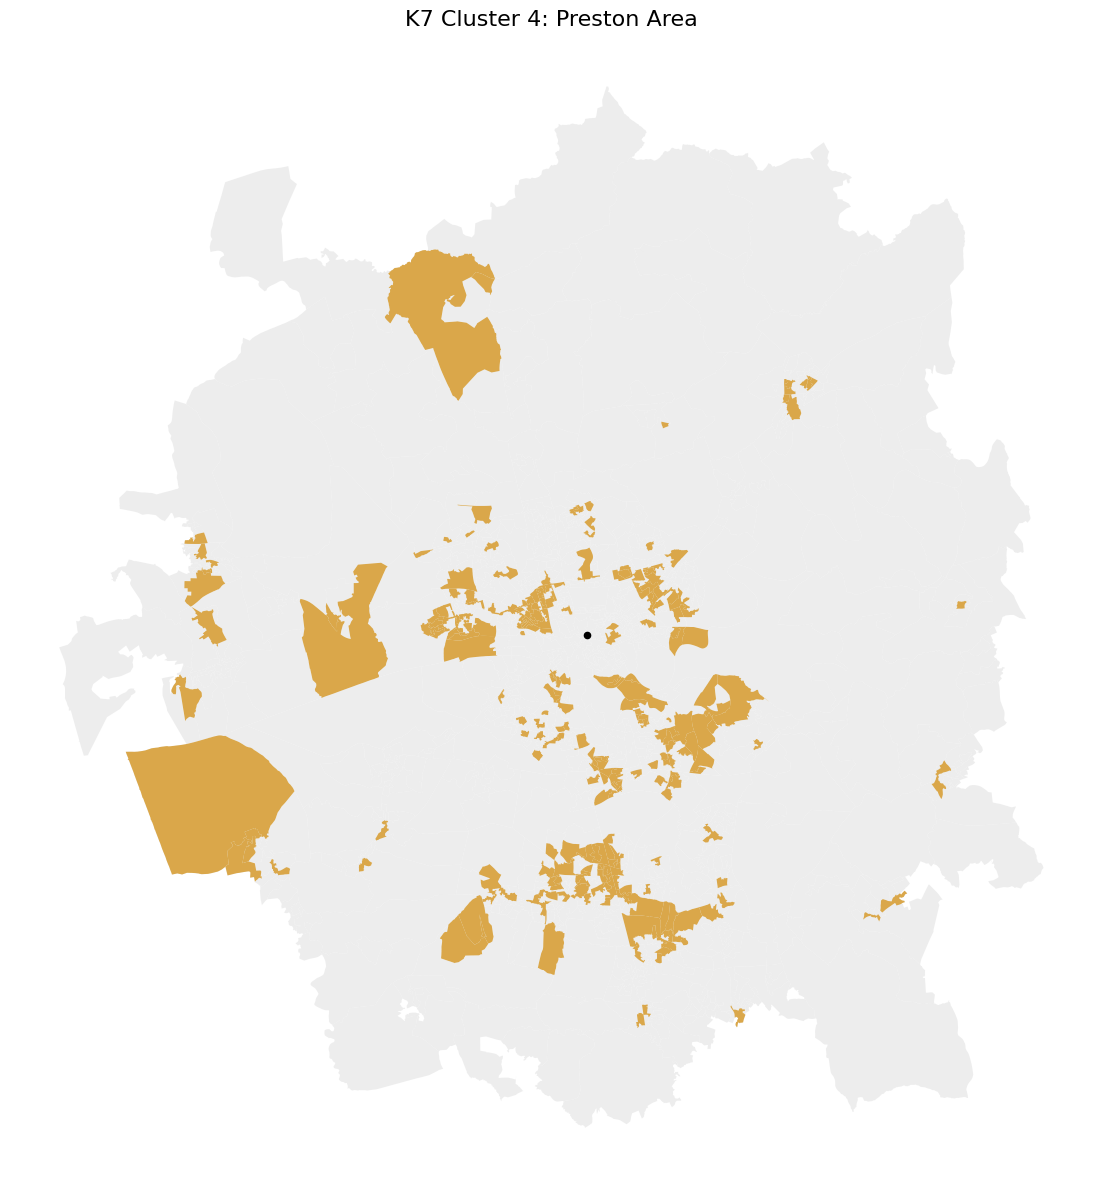

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_4_highlight.png


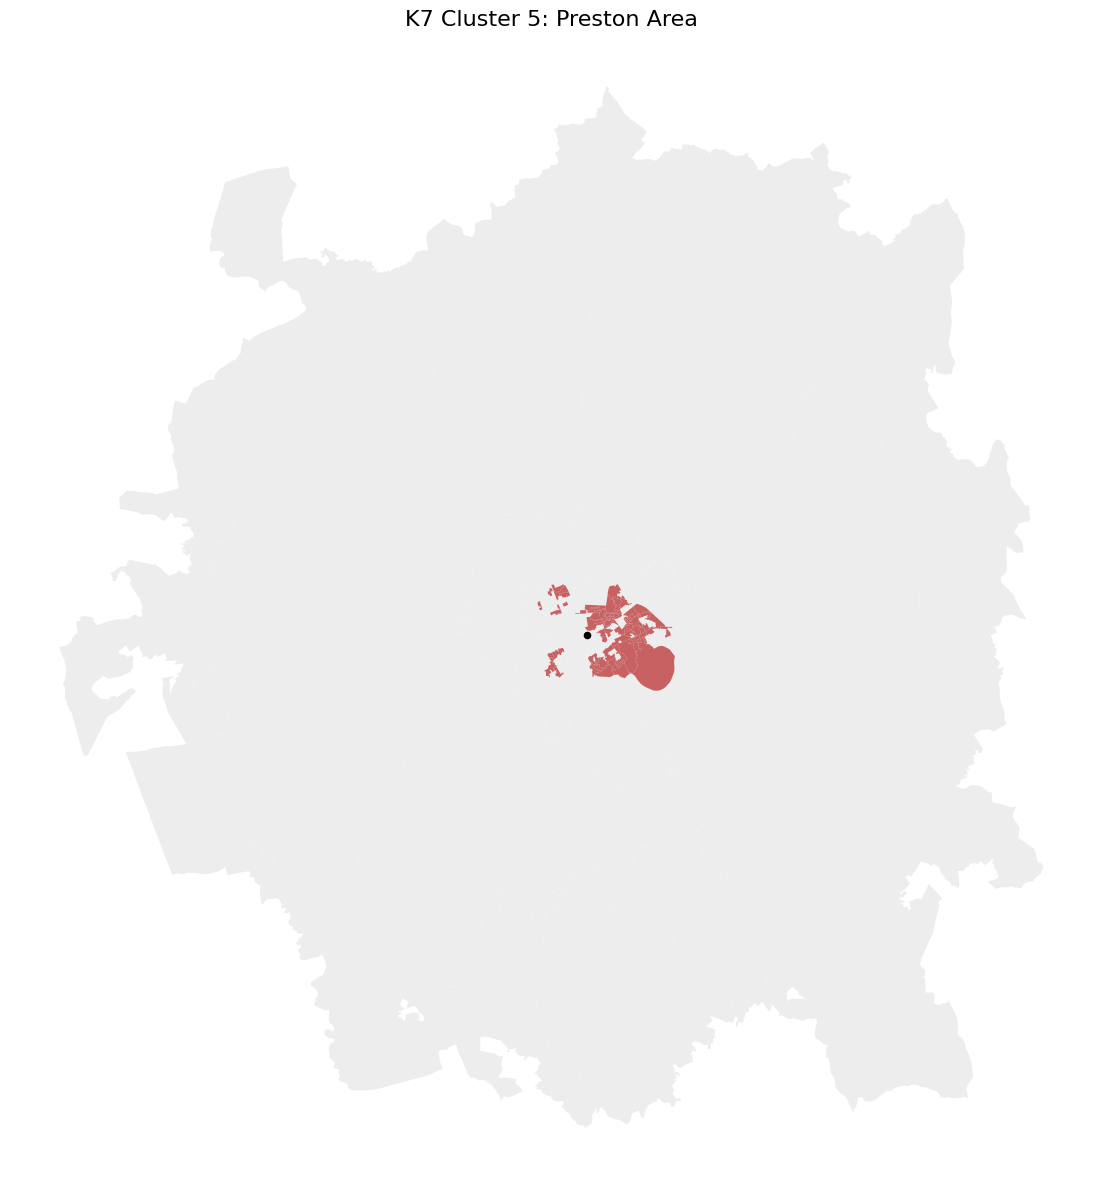

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_5_highlight.png


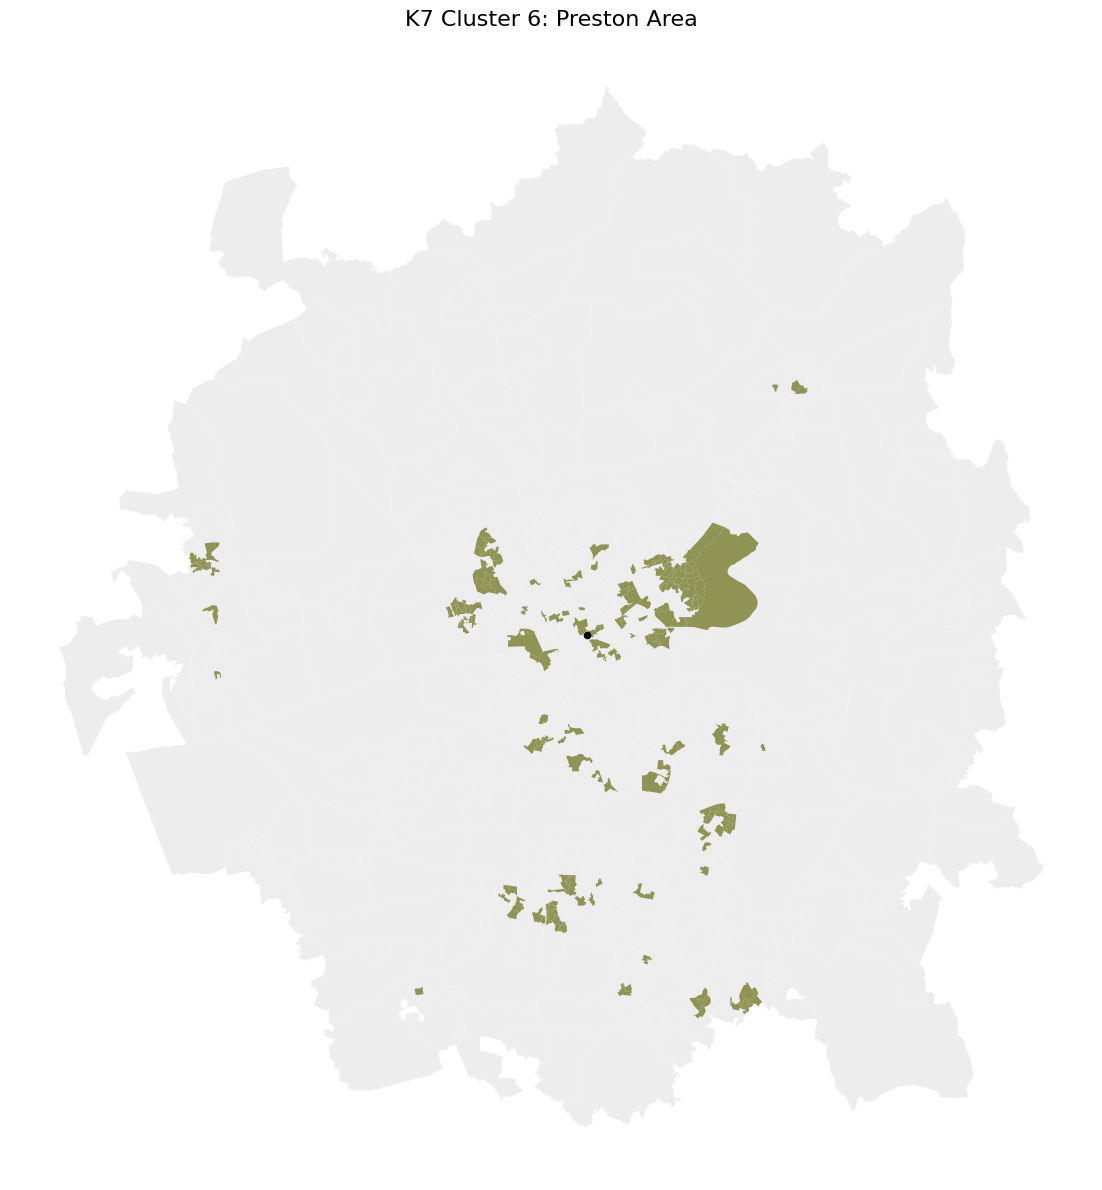

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_cluster_6_highlight.png


In [19]:
for cluster_id in sorted(preston_oa["cluster_id"].unique()):
    fig, ax = plt.subplots(figsize=(12, 12))

    preston_oa.plot(
        ax=ax,
        color="#E6E6E6",
        linewidth=0,
        alpha=0.7
    )

    preston_oa[preston_oa["cluster_id"] == cluster_id].plot(
        ax=ax,
        color=cluster_palette[cluster_id],
        linewidth=0,
        alpha=0.95
    )

    preston_point.plot(
        ax=ax,
        color="black",
        markersize=20
    )

    ax.set_title(f"K7 Cluster {cluster_id}: Preston Area", fontsize=16)
    ax.set_axis_off()

    plt.tight_layout()

    out_path = OUTPUT_DIR / f"k7_preston_cluster_{cluster_id}_highlight.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [20]:
def map_k_assignments(assignments_path, k_label, radius_m=12_000):
    assignments = pd.read_csv(assignments_path).rename(columns={
        "oa_code": "OA21CD",
        "cluster_id": "cluster_id",
        "population": "population"
    })

    assignments["OA21CD"] = assignments["OA21CD"].astype(str).str.strip()
    assignments["cluster_id"] = assignments["cluster_id"].astype(int)

    gdf = oa_boundaries.merge(
        assignments,
        on="OA21CD",
        how="inner",
        validate="one_to_one"
    )

    local = gdf[gdf.intersects(preston_buffer)].copy()

    colours = plt.cm.get_cmap("tab10", local["cluster_id"].nunique())

    fig, ax = plt.subplots(figsize=(10, 10))

    local.plot(
        ax=ax,
        column="cluster_id",
        categorical=True,
        cmap="tab10",
        linewidth=0,
        legend=True
    )

    preston_point.plot(ax=ax, color="black", markersize=20)

    ax.set_title(f"{k_label}: Preston OA Clusters", fontsize=14)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()

    return local

C:\Users\keena\AppData\Local\Temp\ipykernel_3700\1928977201.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap("tab10", local["cluster_id"].nunique())


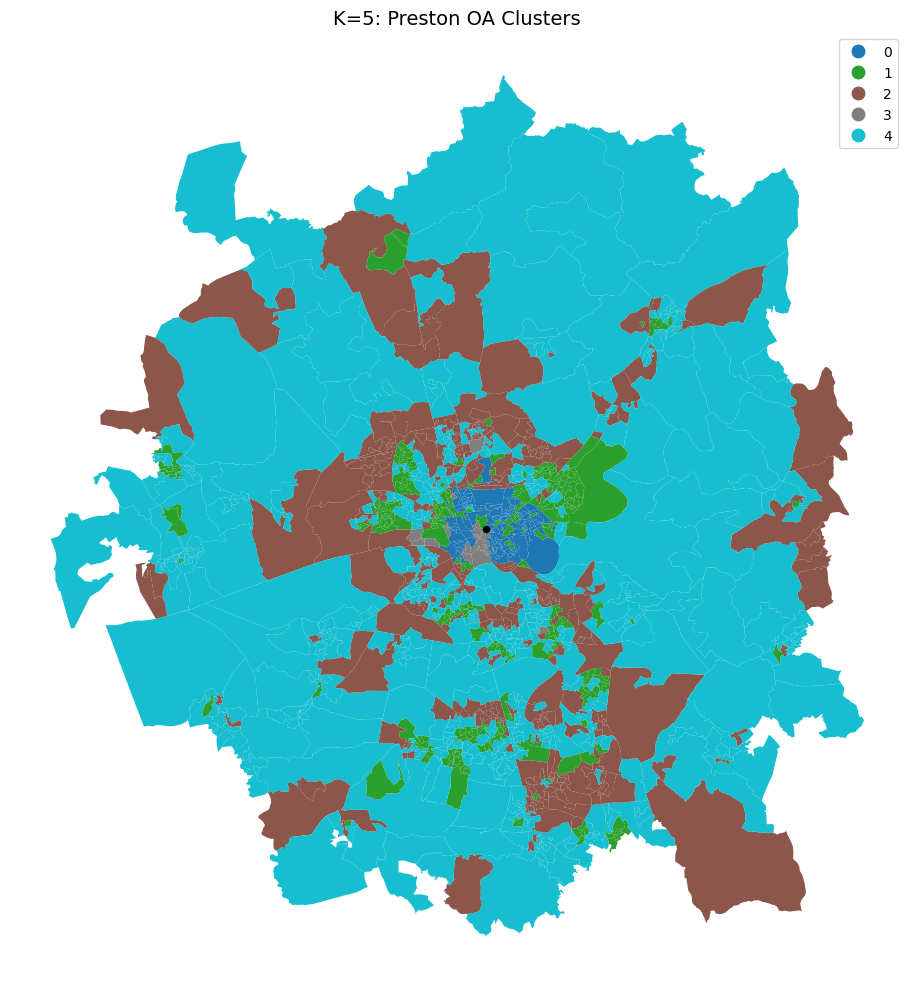

C:\Users\keena\AppData\Local\Temp\ipykernel_3700\1928977201.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap("tab10", local["cluster_id"].nunique())


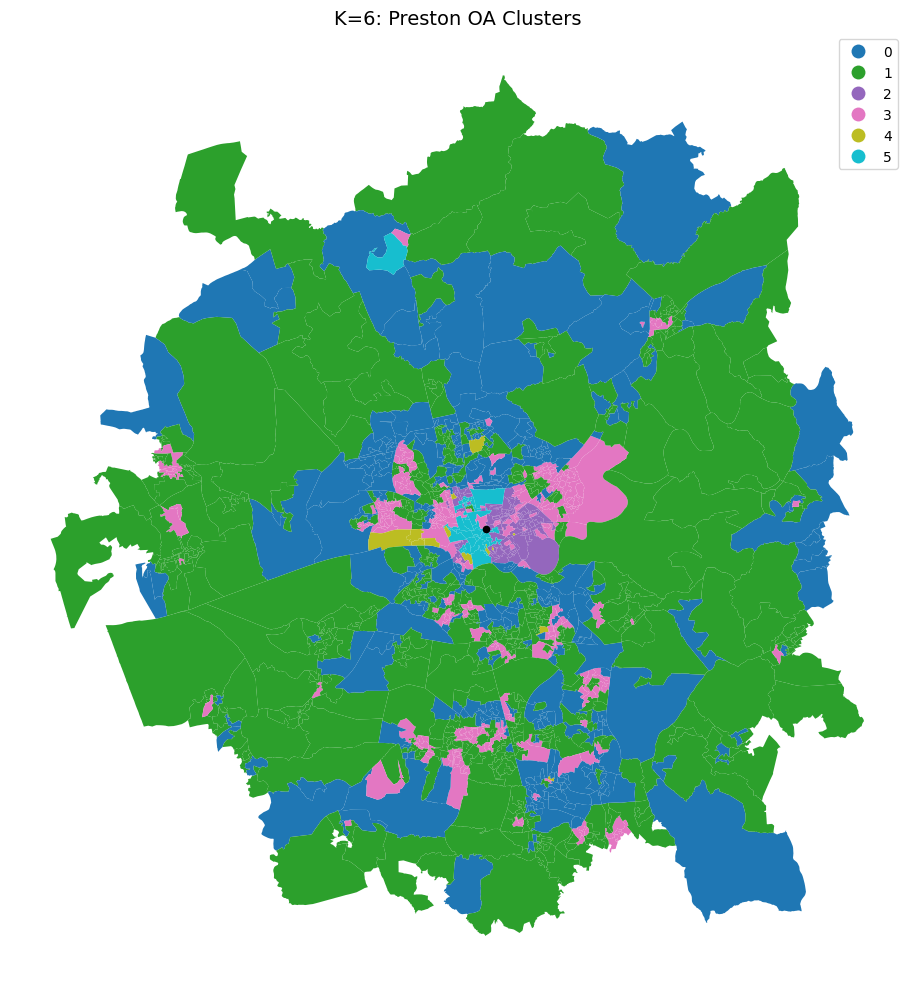

C:\Users\keena\AppData\Local\Temp\ipykernel_3700\1928977201.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap("tab10", local["cluster_id"].nunique())


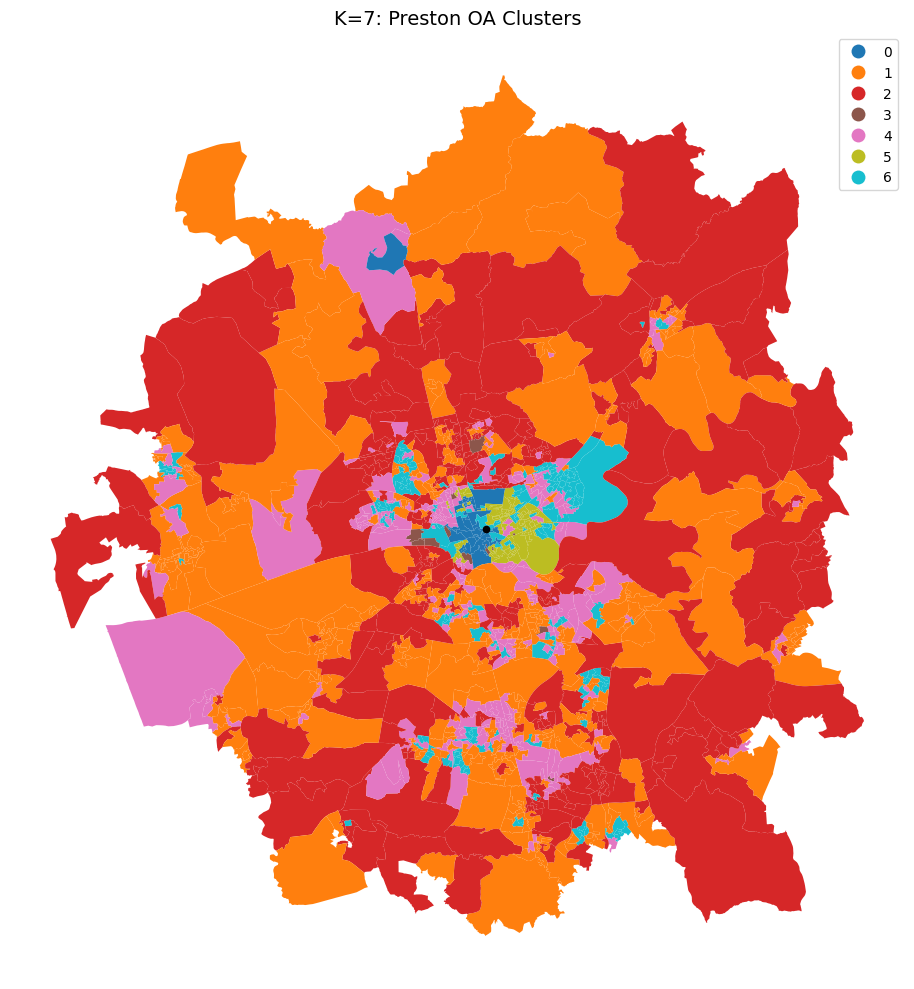

In [21]:
k5_local = map_k_assignments(
    DATA_PROCESSED_DIR / "k_comparison_outputs_v1" / "oa_assignments" / "k5_oa_cluster_assignments_v1.csv",
    "K=5"
)

k6_local = map_k_assignments(
    DATA_PROCESSED_DIR / "k_comparison_outputs_v1" / "oa_assignments" / "k6_oa_cluster_assignments_v1.csv",
    "K=6"
)

k7_local = map_k_assignments(
    DATA_PROCESSED_DIR / "k_comparison_outputs_v1" / "oa_assignments" / "k7_oa_cluster_assignments_v1.csv",
    "K=7"
)

In [25]:
import pyogrio
import geopandas as gpd

# Inspect layers first
pyogrio.list_layers(WARD_BOUNDARIES_PATH)

array([['WD_MAY_2025_UK_BFC_V2', 'MultiPolygon']], dtype=object)

In [26]:
wards = gpd.read_file(WARD_BOUNDARIES_PATH)

print(wards.shape)
print(wards.columns.tolist())
print(wards.crs)
display(wards.head())

(8405, 12)
['WD25CD', 'WD25NM', 'WD25NMW', 'LAD25CD', 'LAD25NM', 'LAD25NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']
EPSG:27700


,WD25CD,WD25NM,WD25NMW,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E05000932,Ainsdale,,E08000014,Sefton,,330510,412099,-3.051551,53.600845,{A793F2D4-8C69-494A-8705-0234461F2584},"MULTIPOLYGON (((333004.896 413223.595, 332975...."
1,E05000933,Birkdale,,E08000014,Sefton,,333046,414534,-3.013759,53.623059,{66450E5D-FD8B-48CE-AD7C-6F6412E918DD},"MULTIPOLYGON (((334138.402 414944.403, 334123...."
2,E05000934,Blundellsands,,E08000014,Sefton,,330806,399928,-3.044382,53.491506,{7A6556B0-F7A9-487F-B8DC-DFB1C659E47F},"MULTIPOLYGON (((332044.396 399981.496, 332044...."
3,E05000935,Cambridge,,E08000014,Sefton,,334745,419336,-2.989087,53.666428,{69707C25-A3BF-4B96-91F7-2B310C0E0CEC},"MULTIPOLYGON (((335388.299 421924.353, 335381...."
4,E05000936,Church,,E08000014,Sefton,,332033,397634,-3.025395,53.471050,{00BB4E9F-6F02-42B7-97D5-68CCB6F5A2DC},"MULTIPOLYGON (((332791.399 398377.705, 332771...."


In [29]:
possible_ward_code_cols = ["WD25CD", "WD24CD", "WD23CD", "wd25cd", "ward_code"]
possible_ward_name_cols = ["WD25NM", "WD24NM", "WD23NM", "wd25nm", "ward_name"]

ward_code_col = None
ward_name_col = None

for col in possible_ward_code_cols:
    if col in wards.columns:
        ward_code_col = col
        break

for col in possible_ward_name_cols:
    if col in wards.columns:
        ward_name_col = col
        break

if ward_code_col is None:
    raise KeyError("Could not identify ward code column.")

if ward_name_col is None:
    raise KeyError("Could not identify ward name column.")

wards = wards.rename(columns={
    ward_code_col: "WARD_CODE",
    ward_name_col: "WARD_NAME"
})

wards = wards[["WARD_CODE", "WARD_NAME", "geometry"]].copy()

In [30]:
if wards.crs is None:
    wards = wards.set_crs(27700)

if wards.crs.to_epsg() != 27700:
    wards = wards.to_crs(27700)

print(wards.crs)

EPSG:27700


In [31]:
preston_wards = wards[wards.intersects(preston_buffer)].copy()

print(preston_wards.shape)
display(preston_wards[["WARD_CODE", "WARD_NAME"]].head(20))

(68, 3)


,WARD_CODE,WARD_NAME
1318,E05009934,Brock with Catterall
1323,E05009939,Great Eccleston
1467,E05010214,Bamber Bridge East
1468,E05010215,Bamber Bridge West
1469,E05010216,Broad Oak
1470,E05010217,Broadfield
1471,E05010218,Buckshaw & Worden
1472,E05010219,Charnock
1473,E05010220,Coupe Green & Gregson Lane
1474,E05010221,Earnshaw Bridge


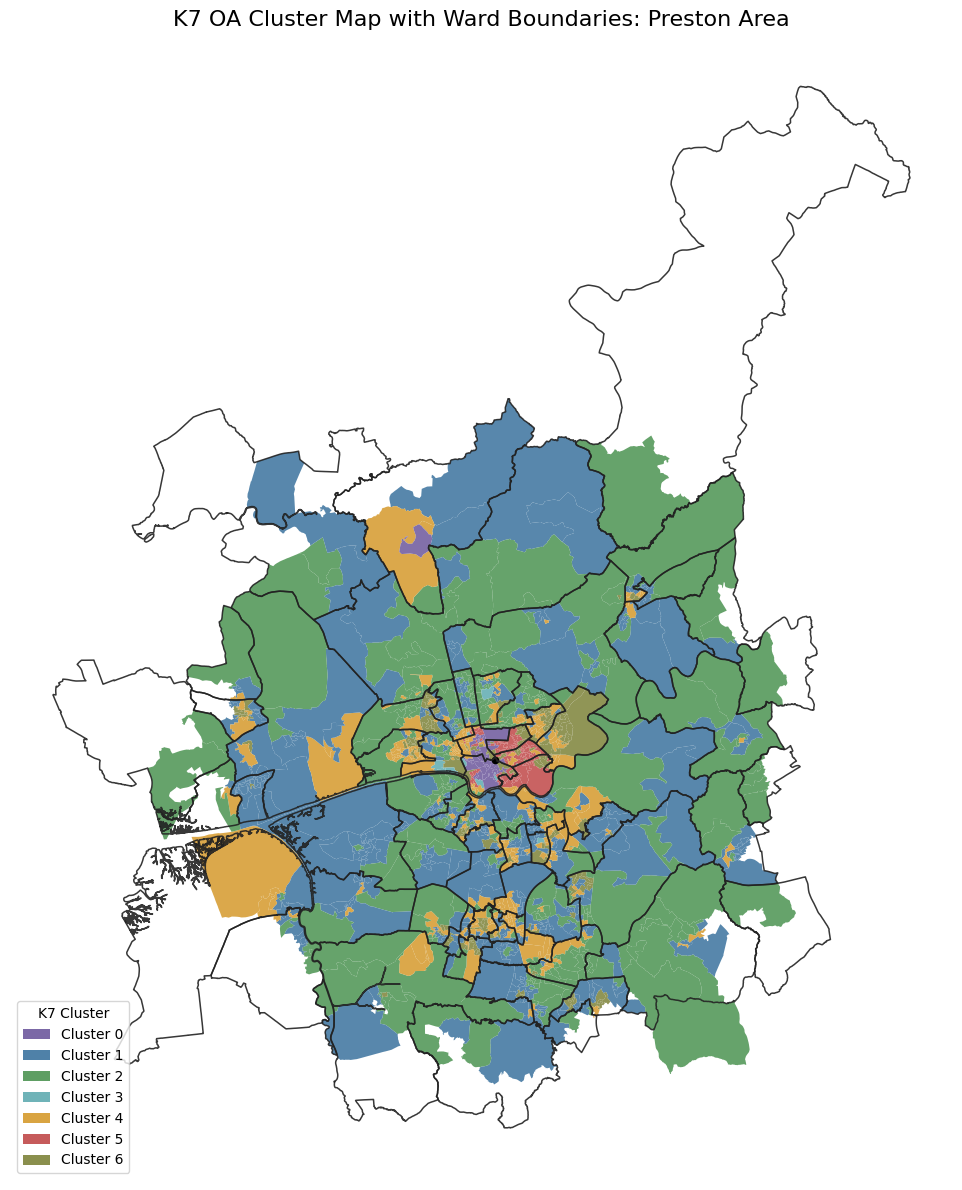

Saved: c:\Users\keena\Documents\Electoral_Tribes\outputs\maps\k7_preston\k7_preston_oa_clusters_with_ward_boundaries.png


In [38]:
legend_items = [
    Patch(facecolor=cluster_palette[i], label=f"Cluster {i}")
    for i in sorted(preston_oa["cluster_id"].unique())
]

fig, ax = plt.subplots(figsize=(12, 12))

# Filled OA cluster layer
preston_oa.plot(
    ax=ax,
    color=preston_oa["cluster_colour"],
    linewidth=0,
    alpha=0.95
)

# Ward boundary overlay
preston_wards.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.1,
    alpha=0.9
)

# Preston point
preston_point.plot(
    ax=ax,
    color="black",
    markersize=20
)

ax.legend(
    handles=legend_items,
    title="K7 Cluster",
    loc="lower left",
    frameon=True
)

ax.set_title("K7 OA Cluster Map with Ward Boundaries: Preston Area", fontsize=16)
ax.set_axis_off()

plt.tight_layout()

out_path = OUTPUT_DIR / "k7_preston_oa_clusters_with_ward_boundaries.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

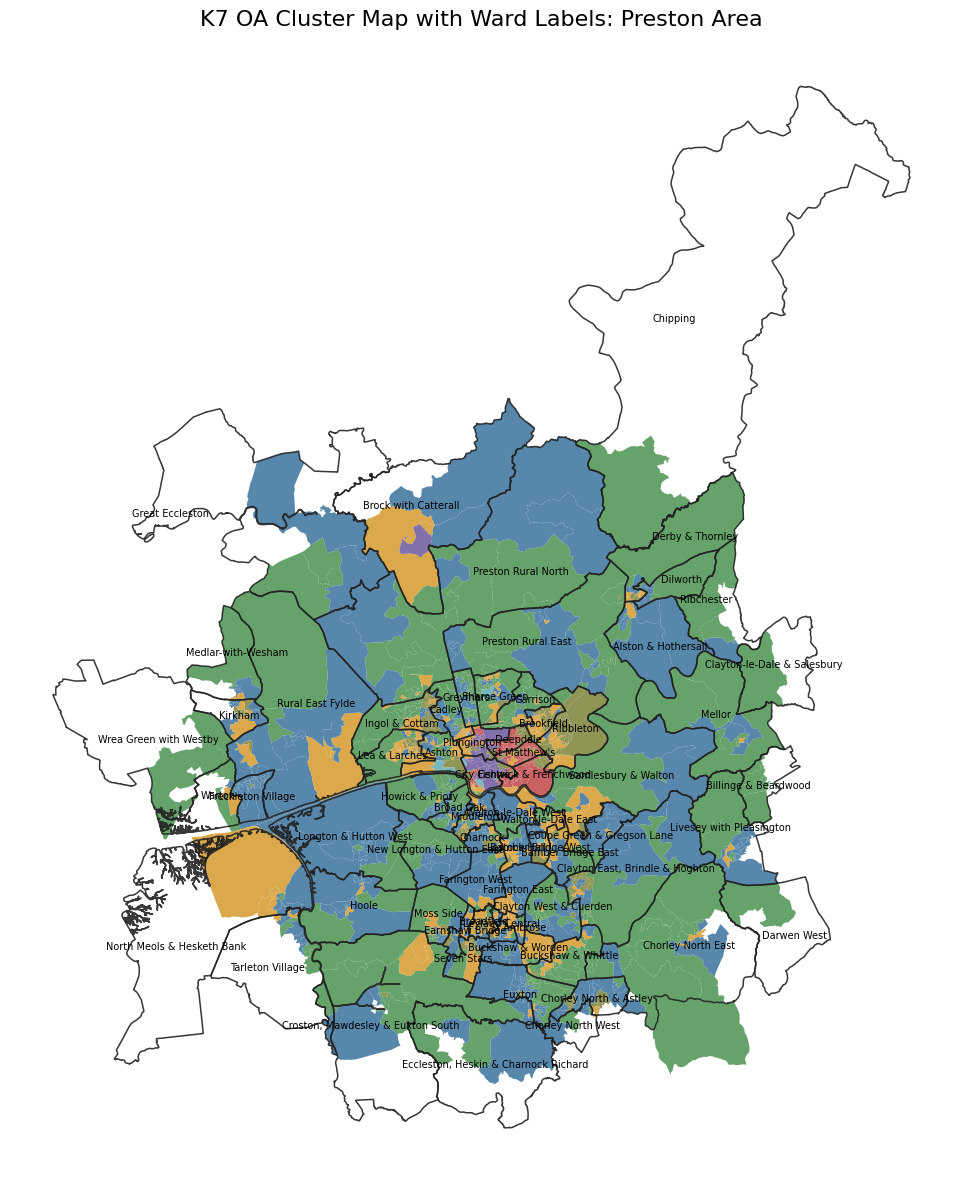

In [37]:
label_points = preston_wards.copy()
label_points["geometry"] = label_points.geometry.representative_point()

fig, ax = plt.subplots(figsize=(12, 12))

preston_oa.plot(
    ax=ax,
    color=preston_oa["cluster_colour"],
    linewidth=0,
    alpha=0.95
)

preston_wards.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.1,
    alpha=0.9
)

for _, row in label_points.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["WARD_NAME"],
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title("K7 OA Cluster Map with Ward Labels: Preston Area", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()